# Diagnostic Analysis

The purpose of this diagnostic analysis is to understand correlations between the features and diabetes, as well as correlations among the features themselves. This helps to identify patterns, redundancy, and potential clusters in the dataset.

## Correlation Analysis

A correlation analysis has been conducted to identify relationships between various features and their association with diabetes.  
We analyze correlations for **all features**, and then separately for **socio-economic**, **health**, and **behavioral** features to understand patterns and redundancies.

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pointbiserialr
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn import datasets

In [66]:
diab_df = pd.read_csv("data/diabetes_012_health_indicators_BRFSS2015.csv")

All features are standardized to ensure comparable scales before analysis.  
Standardization converts each feature to have **mean 0** and **standard deviation 1**.

In [67]:
# Standardisation
diab_df_all_std = diab_df.copy()
scaler = StandardScaler()
for elem in diab_df.columns.to_list():
    diab_df_all_std[elem + '_std'] = scaler.fit_transform(diab_df[[elem]])

diab_df_all_std = diab_df.filter(like='_std')

### Correlation Matrix for All Features

We calculate the correlation matrix for all features to identify strong positive and negative relationships with diabetes.  
**Key observations:**
- Strong positive correlation with diabetes: `GenHlth` (0.30), `HighBP` (0.27), `BMI` (0.22), `DiffWalk` (0.22), `HighChol` (0.21), `Age` (0.18)
- Strong negative correlation with diabetes: `Income` (-0.17), `Education` (-0.13), `PhysActivity` (-0.12)
- Weakly correlated features: `Fruits` (-0.04), `Veggies` (-0.06), `Smoker` (0.06), `HvyAlcoholConsump` (0.06), `Sex` (0.03), `AnyHealthcare` (0.02)

In [68]:
corr_matrix = diab_df.corr()
print(corr_matrix)

# only values below the diagonal are kept
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


                      Diabetes_012    HighBP  HighChol  CholCheck       BMI  \
Diabetes_012              1.000000  0.271596  0.209085   0.067546  0.224379   
HighBP                    0.271596  1.000000  0.298199   0.098508  0.213748   
HighChol                  0.209085  0.298199  1.000000   0.085642  0.106722   
CholCheck                 0.067546  0.098508  0.085642   1.000000  0.034495   
BMI                       0.224379  0.213748  0.106722   0.034495  1.000000   
Smoker                    0.062914  0.096991  0.091299  -0.009929  0.013804   
Stroke                    0.107179  0.129575  0.092620   0.024158  0.020153   
HeartDiseaseorAttack      0.180272  0.209361  0.180765   0.044206  0.052904   
PhysActivity             -0.121947 -0.125267 -0.078046   0.004190 -0.147294   
Fruits                   -0.042192 -0.040555 -0.040859   0.023849 -0.087518   
Veggies                  -0.058972 -0.061266 -0.039874   0.006121 -0.062275   
HvyAlcoholConsump        -0.057882 -0.003972 -0.0115

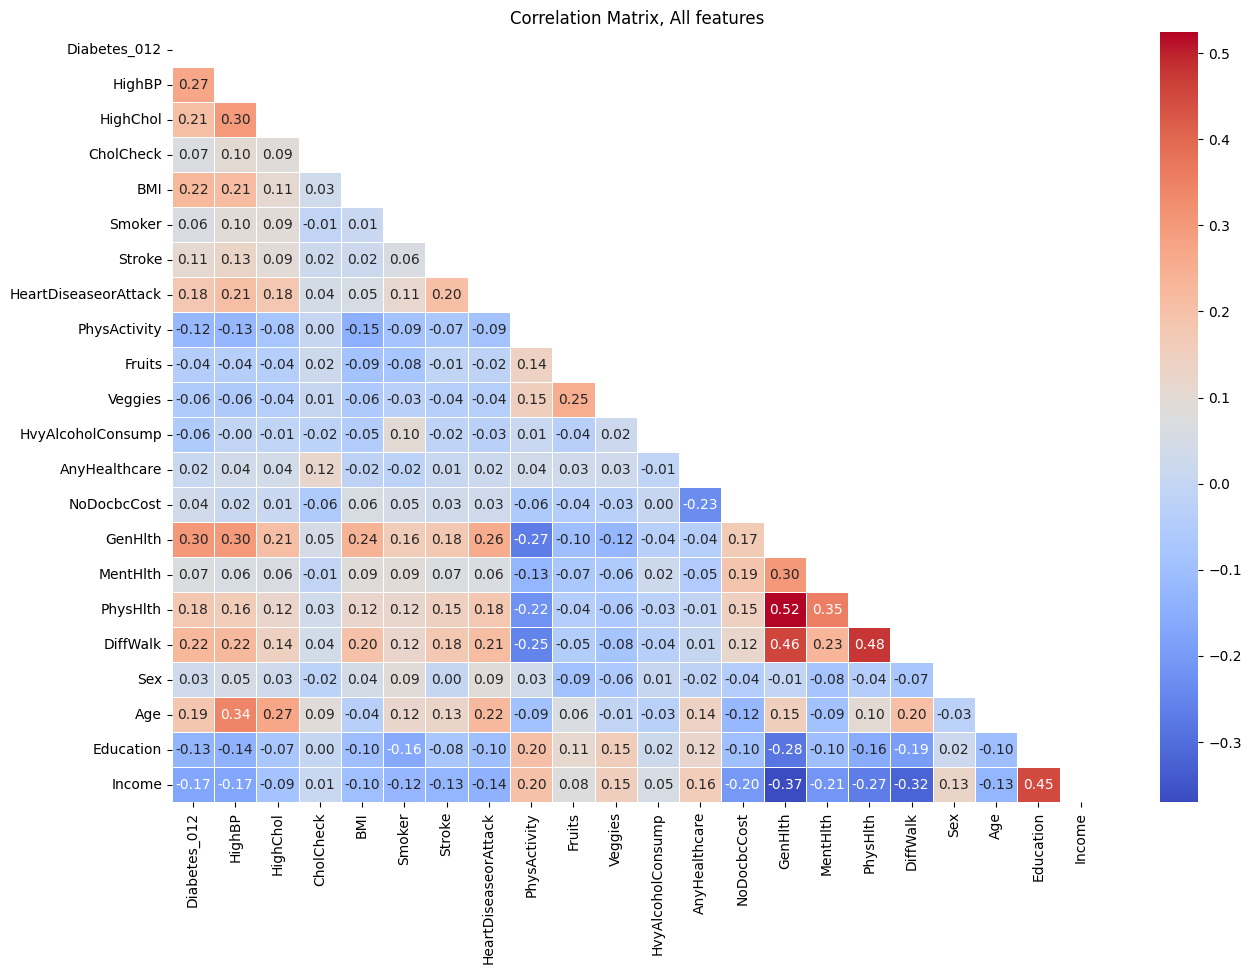

In [69]:
plt.figure(figsize=(15, 10))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix, All features")
plt.show()

### Correlation Matrix: Socio-Economic Features

Selected features: `Diabetes_012`, `Income`, `Education`, `AnyHealthcare`, `NoDocbcCost`.

Observations:
- Education and Income are positively correlated (0.45)
- People who cannot see a doctor due to cost tend to have lower income (-0.20) and education (-0.10)
- Health care coverage has a limited effect on diabetes prevalence
- More privileged individuals with higher income and education are less likely to have diabetes

In [70]:
df_socio = diab_df[['Diabetes_012', 'Income', 'Education', 'AnyHealthcare', 'NoDocbcCost']]
df_socio

,Diabetes_012,Income,Education,AnyHealthcare,NoDocbcCost
0,0.0,3.0,4.0,1.0,0.0
1,0.0,1.0,6.0,0.0,1.0
2,0.0,8.0,4.0,1.0,1.0
3,0.0,6.0,3.0,1.0,0.0
4,0.0,4.0,5.0,1.0,0.0
...,...,...,...,...,...
253675,0.0,7.0,6.0,1.0,0.0
253676,2.0,4.0,2.0,1.0,0.0
253677,0.0,2.0,5.0,1.0,0.0
253678,0.0,1.0,5.0,1.0,0.0


In [71]:
corr_matrix = df_socio.corr()
print(corr_matrix)

# only values below the diagonal are kept
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

               Diabetes_012    Income  Education  AnyHealthcare  NoDocbcCost
Diabetes_012       1.000000 -0.171483  -0.130517       0.015410     0.035436
Income            -0.171483  1.000000   0.449106       0.157999    -0.203182
Education         -0.130517  0.449106   1.000000       0.122514    -0.100701
AnyHealthcare      0.015410  0.157999   0.122514       1.000000    -0.232532
NoDocbcCost        0.035436 -0.203182  -0.100701      -0.232532     1.000000


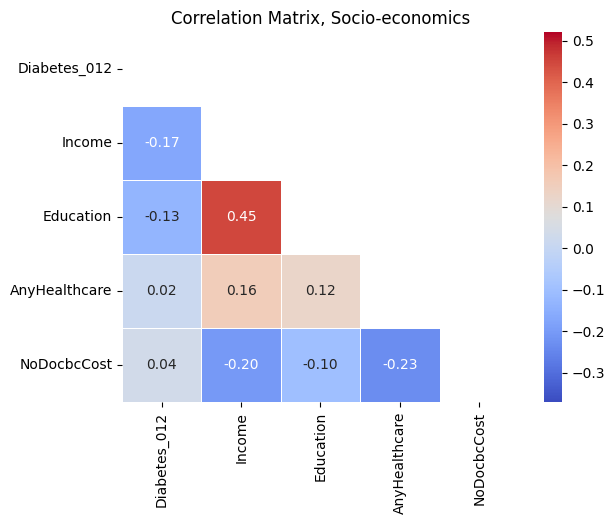

In [72]:
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", vmin=-0.37, vmax=0.52, linewidths=0.5)
plt.title("Correlation Matrix, Socio-economics")
plt.show()

### Correlation Matrix: Health Features

Selected features: `HighChol`, `CholCheck`, `HighBP`, `DiffWalk`, `BMI`, `HeartDiseaseorAttack`, `Stroke`, `GenHlth`, `PhysHlth`, `MentHlth`.

Observations:
- Most health features are highly positively correlated with diabetes
- Poor health conditions tend to co-occur, creating cohesive positive correlations
- `CholCheck` is poorly linked with other health features

In [73]:
df_hlth = diab_df[['Diabetes_012', 'HighChol', 'CholCheck', 'HighBP', 'DiffWalk', 'BMI', 'HeartDiseaseorAttack', 'Stroke', 'GenHlth', 'PhysHlth', 'MentHlth']]

In [74]:
corr_matrix = df_hlth.corr()
print(corr_matrix)

# only values below the diagonal are kept
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

                      Diabetes_012  HighChol  CholCheck    HighBP  DiffWalk  \
Diabetes_012              1.000000  0.209085   0.067546  0.271596  0.224239   
HighChol                  0.209085  1.000000   0.085642  0.298199  0.144672   
CholCheck                 0.067546  0.085642   1.000000  0.098508  0.040585   
HighBP                    0.271596  0.298199   0.098508  1.000000  0.223618   
DiffWalk                  0.224239  0.144672   0.040585  0.223618  1.000000   
BMI                       0.224379  0.106722   0.034495  0.213748  0.197078   
HeartDiseaseorAttack      0.180272  0.180765   0.044206  0.209361  0.212709   
Stroke                    0.107179  0.092620   0.024158  0.129575  0.176567   
GenHlth                   0.302587  0.208426   0.046589  0.300530  0.456920   
PhysHlth                  0.176287  0.121751   0.031775  0.161212  0.478417   
MentHlth                  0.073507  0.062069  -0.008366  0.056456  0.233688   

                           BMI  HeartDiseaseorAttac

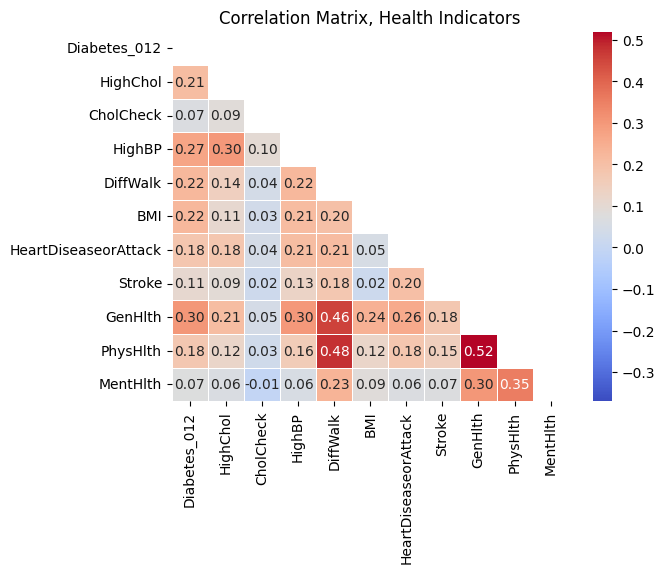

In [75]:
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", vmin=-0.37, vmax=0.52, linewidths=0.5)
plt.title("Correlation Matrix, Health Indicators")
plt.show()

### Correlation Matrix: Behavioral Features

Selected features: `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump`.

Observations:
- Strong positive correlation between `Fruits` and `Veggies` consumption (0.25)
- Physically active people tend to eat more fruits and vegetables (0.15 and 0.14)
- These behaviors are slightly negatively correlated with difficulty walking (-0.25) and diabetes
- Other correlations are generally weak, suggesting behaviors alone are not strong predictors

In [76]:
diab_df_bhv = diab_df[['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']]

In [77]:
corr_matrix = diab_df_bhv.corr()
print(corr_matrix)

# only values below the diagonal are kept
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

                     Smoker  PhysActivity    Fruits   Veggies  \
Smoker             1.000000     -0.087401 -0.077666 -0.030678   
PhysActivity      -0.087401      1.000000  0.142756  0.153150   
Fruits            -0.077666      0.142756  1.000000  0.254342   
Veggies           -0.030678      0.153150  0.254342  1.000000   
HvyAlcoholConsump  0.101619      0.012392 -0.035288  0.021064   

                   HvyAlcoholConsump  
Smoker                      0.101619  
PhysActivity                0.012392  
Fruits                     -0.035288  
Veggies                     0.021064  
HvyAlcoholConsump           1.000000  


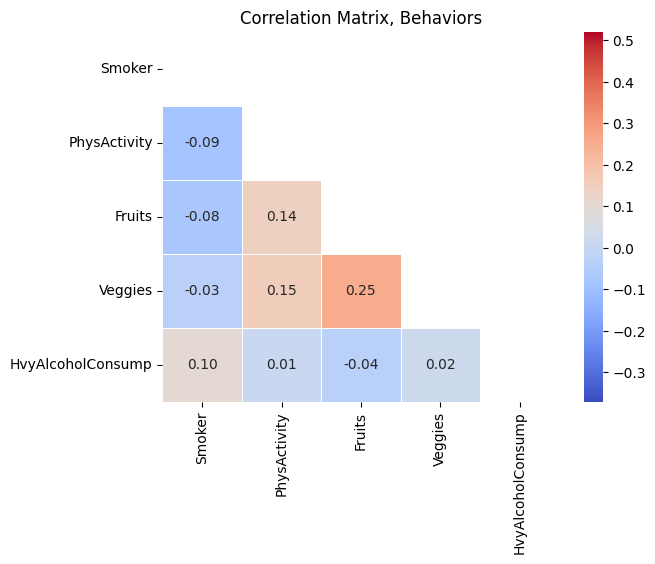

In [78]:
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", vmin=-0.37, vmax=0.52, linewidths=0.5)
plt.title("Correlation Matrix, Behaviors")
plt.show()

### Conclusions from Correlation Analysis

- Features weakly correlated with diabetes: `Fruits`, `Veggies`, `HvyAlcoholConsump`, `AnyHealthcare`, `NoDocbcCost`, `Sex`
- Socio-economic matrix indicates that higher education and income reduce diabetes risk
- Health features are highly inter-correlated, with poor health conditions reinforcing one another
- Behavioral features show limited correlation with diabetes, except for minor positive influence from physical activity and healthy diet
- These matrices can inform future feature selection and preprocessing for predictive modeling

# Clustering

The dataset is divided into clusters using the **K-means** model.  
The objective is to divide the data with an **unsupervised learning method** to see if the diabetic categories emerge naturally from the dataset.  
We start by clustering the full dataset and then repeat the analysis using only selected features relevant to biological causes of diabetes.

# Clustering on the Full Dataset

We first drop the target variable **`Diabetes_012`** and standardize all features to apply K-means clustering.
The number of clusters is chosen as **2** because pre-diabetics represent less than 2% of patients.

In [79]:
df_2 = df.drop(columns=['Diabetes_012'])

# Standardize features
scaler = StandardScaler()
df_std = scaler.fit_transform(df_2)

In [80]:
# Create k-mean object
cluster = KMeans(n_clusters=2, random_state=0)

# Train model
model = cluster.fit(df_std)

# View predict class
model.labels_

df['cluster'] = model.labels_

The results demonstrate that non-diabetics are mostly in **cluster 0** and nearly absent from **cluster 2**, meaning non-diabetics are well identified in cluster 0.  
Pre-diabetics are equally split between clusters 0 and 1, which indicates they are not well identified, but the low number of patients suffering from prediabetes does not strongly influence the study.  
Diabetics are represented in all clusters, highlighting that the original dataset does not allow a clear separation of diabetics.

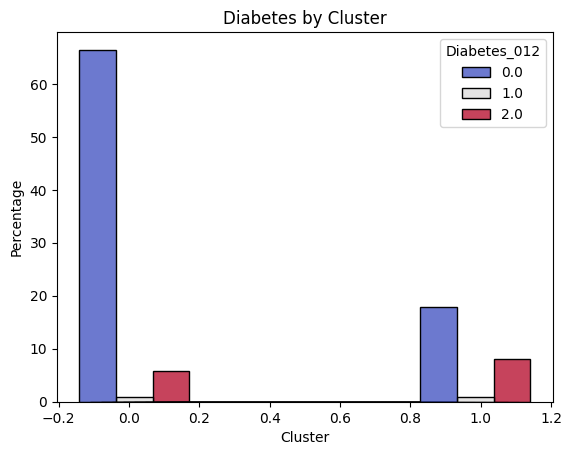

In [81]:
sns.histplot(df, x='cluster', hue='Diabetes_012', multiple='dodge', stat='percent', shrink=10, palette='coolwarm')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.title('Diabetes by Cluster')
plt.show()

## Clustering Using Selected Biological Features

We now select the most relevant features for diabetes: **BMI, High Blood Pressure, Physical Activity, Fruits, Income, and Age**.  
The purpose is to see if K-means can separate diabetics and non-diabetics when only these features are considered.

In [82]:
new_df = df[['Income',  'BMI', 'HighBP', 'Age', 'PhysActivity', 'Fruits']]

In [83]:
new_df_std = scaler.fit_transform(new_df)

In [84]:
# Create k-mean object
cluster = KMeans(n_clusters=2, random_state=0)

# Train model
model = cluster.fit(new_df_std)

# View predict class
model.labels_

df['cluster_without_diabetes'] = model.labels_

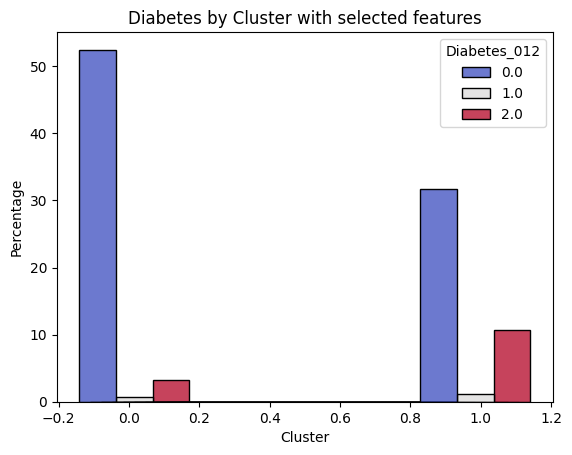

In [85]:
sns.histplot(df, x='cluster_without_diabetes', hue='Diabetes_012', stat='percent', multiple='dodge', shrink=10, palette='coolwarm')
plt.xlabel('Cluster')
plt.ylabel('Percentage')
plt.title('Diabetes by Cluster with selected features')
plt.show()

When clustering is performed using only the most relevant features:

- Diabetics are mostly concentrated in **cluster 1**, but some non-diabetics are also present.
- The unsupervised K-means model **does not naturally separate diabetics from non-diabetics** even when using only the most important features.
- Alternative methods like DBSCAN were attempted, but they generated too many clusters (>100), providing no meaningful separation.
- Overall, the dataset does not contain naturally separable clusters for diabetic status using these features.

This confirms that **unsupervised clustering alone cannot clearly identify diabetic patients** in this dataset.